In [260]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [261]:
train_csv = pd.read_csv('data/train.csv')
test_csv = pd.read_csv('data/test.csv')

In [262]:
train_csv.columns

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [263]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


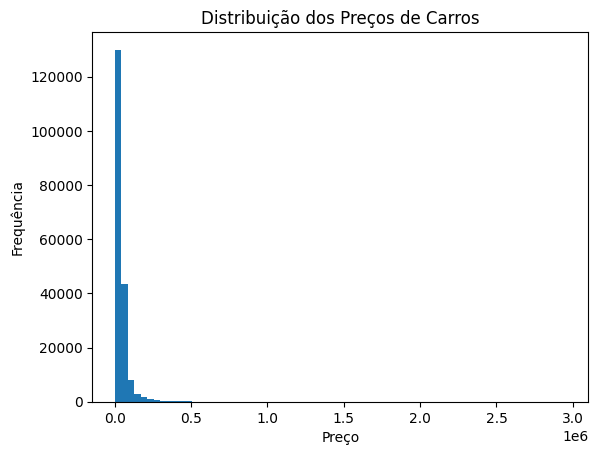

In [264]:
plt.hist(train_csv['price'], bins=70)
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.title('Distribuição dos Preços de Carros')
plt.show()

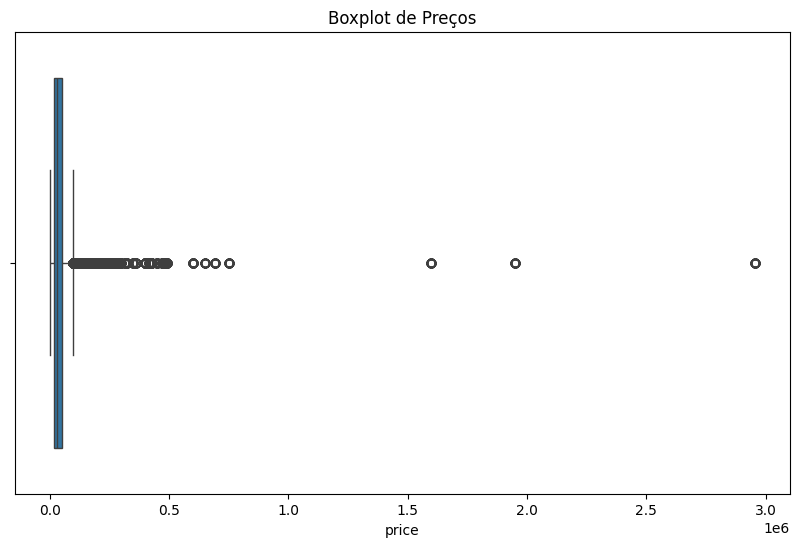

In [265]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=train_csv['price'])
plt.title('Boxplot de Preços')
plt.show()

In [266]:
numerical_cols = train_csv.select_dtypes(include=np.number)
train_csv = train_csv.drop(columns=['id'])

In [267]:
display(numerical_cols)

,id,model_year,milage,price
0,0,2007,213000,4200
1,1,2002,143250,4999
2,2,2002,136731,13900
3,3,2017,19500,45000
4,4,2021,7388,97500
...,...,...,...,...
188528,188528,2017,49000,27500
188529,188529,2018,28600,30000
188530,188530,2021,13650,86900
188531,188531,2022,13895,84900


In [268]:
train_csv.fillna(numerical_cols.median(), inplace=True)

In [269]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188533 non-null  object
 1   model         188533 non-null  object
 2   model_year    188533 non-null  int64 
 3   milage        188533 non-null  int64 
 4   fuel_type     183450 non-null  object
 5   engine        188533 non-null  object
 6   transmission  188533 non-null  object
 7   ext_col       188533 non-null  object
 8   int_col       188533 non-null  object
 9   accident      186081 non-null  object
 10  clean_title   167114 non-null  object
 11  price         188533 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 17.3+ MB


In [270]:
train_csv.isna().sum()[train_csv.isna().sum() > 0]

fuel_type       5083
accident        2452
clean_title    21419
dtype: int64

In [271]:
(train_csv.isna().mean() * 100).sort_values(ascending=False)

clean_title     11.360876
fuel_type        2.696080
accident         1.300568
brand            0.000000
milage           0.000000
model_year       0.000000
model            0.000000
engine           0.000000
ext_col          0.000000
transmission     0.000000
int_col          0.000000
price            0.000000
dtype: float64

In [272]:
train_csv['clean_title'].fillna('Unknown', inplace=True)

In [273]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188533 non-null  object
 1   model         188533 non-null  object
 2   model_year    188533 non-null  int64 
 3   milage        188533 non-null  int64 
 4   fuel_type     183450 non-null  object
 5   engine        188533 non-null  object
 6   transmission  188533 non-null  object
 7   ext_col       188533 non-null  object
 8   int_col       188533 non-null  object
 9   accident      186081 non-null  object
 10  clean_title   188533 non-null  object
 11  price         188533 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 17.3+ MB


In [274]:
train_csv.isna()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
188528,False,False,False,False,False,False,False,False,False,False,False,False
188529,False,False,False,False,False,False,False,False,False,False,False,False
188530,False,False,False,False,False,False,False,False,False,False,False,False
188531,False,False,False,False,False,False,False,False,False,False,False,False


In [275]:
train_csv = train_csv.dropna()

In [276]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181067 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         181067 non-null  object
 1   model         181067 non-null  object
 2   model_year    181067 non-null  int64 
 3   milage        181067 non-null  int64 
 4   fuel_type     181067 non-null  object
 5   engine        181067 non-null  object
 6   transmission  181067 non-null  object
 7   ext_col       181067 non-null  object
 8   int_col       181067 non-null  object
 9   accident      181067 non-null  object
 10  clean_title   181067 non-null  object
 11  price         181067 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 18.0+ MB


In [277]:
train_csv = train_csv[train_csv['price'] <= 150000]

In [278]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176137 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         176137 non-null  object
 1   model         176137 non-null  object
 2   model_year    176137 non-null  int64 
 3   milage        176137 non-null  int64 
 4   fuel_type     176137 non-null  object
 5   engine        176137 non-null  object
 6   transmission  176137 non-null  object
 7   ext_col       176137 non-null  object
 8   int_col       176137 non-null  object
 9   accident      176137 non-null  object
 10  clean_title   176137 non-null  object
 11  price         176137 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 17.5+ MB
